# 02 — Titanic modeling: classification pipeline, imbalance, tuning, regression

**Module 2, Part B.** This notebook continues from `01_eda.ipynb`. It reads the **same committed
`titanic.csv`** that the EDA notebook saved, and it never calls `sns.load_dataset` again.

Target: **`survived`** (binary classification). Every preprocessing step lives inside a scikit-learn
`Pipeline`/`ColumnTransformer`, so it is fitted on the training split only, by construction.

## 0. Setup

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error, precision_score, r2_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)
RANDOM_STATE = 42
FIG_DIR, MODEL_DIR = Path("figures"), Path("models")
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=110, bbox_inches="tight")

## 1. Continue from the committed `titanic.csv`

Same row-level rule as the EDA: `embarked` is missing for 0.22 % of rows (under 5 %), so those 2 rows are dropped.
Dropping rows based only on their *own* missing value uses no dataset statistics, so it is safe to do before
the split. Everything that *learns* from the data (the imputation medians, the encoders, the scaler) happens
inside the pipeline, after the split.

In [2]:
df = pd.read_csv("titanic.csv")                 # the one dataset saved by 01_eda.ipynb
df = df.dropna(subset=["embarked"]).reset_index(drop=True)
print("Rows after dropping missing embarked:", len(df))

NUM_FEATURES = ["pclass", "age", "sibsp", "parch", "fare"]
CAT_FEATURES = ["sex", "embarked"]
FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = "survived"

X, y = df[FEATURES], df[TARGET]
print("Features used:", FEATURES)
print("Missing values per feature (raw):", X.isna().sum()[X.isna().sum() > 0].to_dict())

Rows after dropping missing embarked: 889
Features used: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']
Missing values per feature (raw): {'age': 177}


**Feature choice.** The model uses `pclass, age, sibsp, parch, fare, sex, embarked`, the raw passenger attributes
the EDA identified as informative. The rest are left out:

- **`alive`** is excluded because it is the target written as yes/no. Using it would be pure target leakage.
- **`class`, `who`, `adult_male`, `embark_town` and `alone`** are excluded because they only re-encode columns
  already used.
- **`deck`** is excluded because it is 77 % missing.

`age` still contains 177 missing values at this point. They are imputed *inside* the pipeline.

## 2. Stratified train/test split — before any preprocessing

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
balance = pd.DataFrame({
    "full data": y.value_counts(normalize=True),
    "train": y_train.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).mul(100).round(1).rename(index={0: "0 = did not survive %", 1: "1 = survived %"})
print(f"train: {len(X_train)} rows, test: {len(X_test)} rows\n")
print(balance.to_string())

train: 711 rows, test: 178 rows

                       full data  train  test
survived                                     
0 = did not survive %       61.8   61.7  61.8
1 = survived %              38.2   38.3  38.2


**Why stratify.** The target is imbalanced: **61.8 % did not survive and 38.2 % survived** (after the 2 dropped
rows). A plain random 80/20 split could, by chance, put noticeably more or fewer survivors into the 178-row test
set. That would make the test metrics, especially precision, recall and F1 for the minority "survived" class,
unrepresentative and unstable between runs.

`stratify=y` forces both splits to keep the same class ratio. The table confirms it: train 61.7 / 38.3, test
61.8 / 38.2. Every model is then evaluated against the same realistic class mix it will face in practice. The
split is done **before** any preprocessing, so nothing about the test rows can influence the fitted steps.

## 3. Preprocessing pipeline (fit on train only)

| Columns | Step 1 | Step 2 |
|---|---|---|
| numeric: `pclass, age, sibsp, parch, fare` | `SimpleImputer(strategy="median")` | `StandardScaler()` |
| categorical: `sex, embarked` | `SimpleImputer(strategy="most_frequent")` | `OneHotEncoder(handle_unknown="ignore")` |

The `ColumnTransformer` is wrapped in a `Pipeline` together with the estimator. Calling `.fit(X_train, y_train)`
fits the imputers, encoder and scaler **on the training rows only**. `.predict(X_test)` then only *transforms*
the test rows with those already-fitted statistics. Nothing is ever fitted on the test set or on the full
dataset.

Age imputation here uses the plain training median, not the EDA's sex × class medians: a simpler learned
statistic that is easy to keep leak-free. Tree models do not need scaling, but using the identical
preprocessor for all three models keeps the comparison fair.

In [4]:
def make_preprocessor(num_features=NUM_FEATURES, cat_features=CAT_FEATURES):
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", numeric, num_features),
                              ("cat", categorical, cat_features)])

def make_pipeline(estimator):
    return Pipeline([("prep", make_preprocessor()), ("model", estimator)])

## 4. Train three classifiers on the identical split

In [5]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}
fitted = {name: make_pipeline(est).fit(X_train, y_train) for name, est in classifiers.items()}

# Proof that preprocessing statistics come from the training split only
imputer = fitted["Logistic Regression"].named_steps["prep"].named_transformers_["num"].named_steps["impute"]
scaler = fitted["Logistic Regression"].named_steps["prep"].named_transformers_["num"].named_steps["scale"]
print("Imputer medians (fitted)   :", dict(zip(NUM_FEATURES, imputer.statistics_.round(3))))
print("Training-split medians     :", X_train[NUM_FEATURES].median().round(3).to_dict())
print("Full-dataset medians       :", X[NUM_FEATURES].median().round(3).to_dict())
print("Scaler mean of fare (fit)  :", round(scaler.mean_[NUM_FEATURES.index('fare')], 3),
      "| training mean of fare:", round(X_train['fare'].mean(), 3),
      "| full-data mean:", round(X['fare'].mean(), 3))

Imputer medians (fitted)   : {'pclass': np.float64(3.0), 'age': np.float64(28.0), 'sibsp': np.float64(0.0), 'parch': np.float64(0.0), 'fare': np.float64(14.4)}
Training-split medians     : {'pclass': 3.0, 'age': 28.0, 'sibsp': 0.0, 'parch': 0.0, 'fare': 14.4}
Full-dataset medians       : {'pclass': 3.0, 'age': 28.0, 'sibsp': 0.0, 'parch': 0.0, 'fare': 14.454}
Scaler mean of fare (fit)  : 31.857 | training mean of fare: 31.857 | full-data mean: 32.097


**Leakage check.** The imputer's learned medians equal the **training-split** medians, and the scaler's learned
mean of `fare` equals the **training** mean (31.857). It does not equal the full-data mean (32.097). This
confirms that the preprocessing statistics were learned from the training rows only, and that the test rows are
only ever transformed with them.

### Decision tree visualized with `plot_tree`

Encoded feature names: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


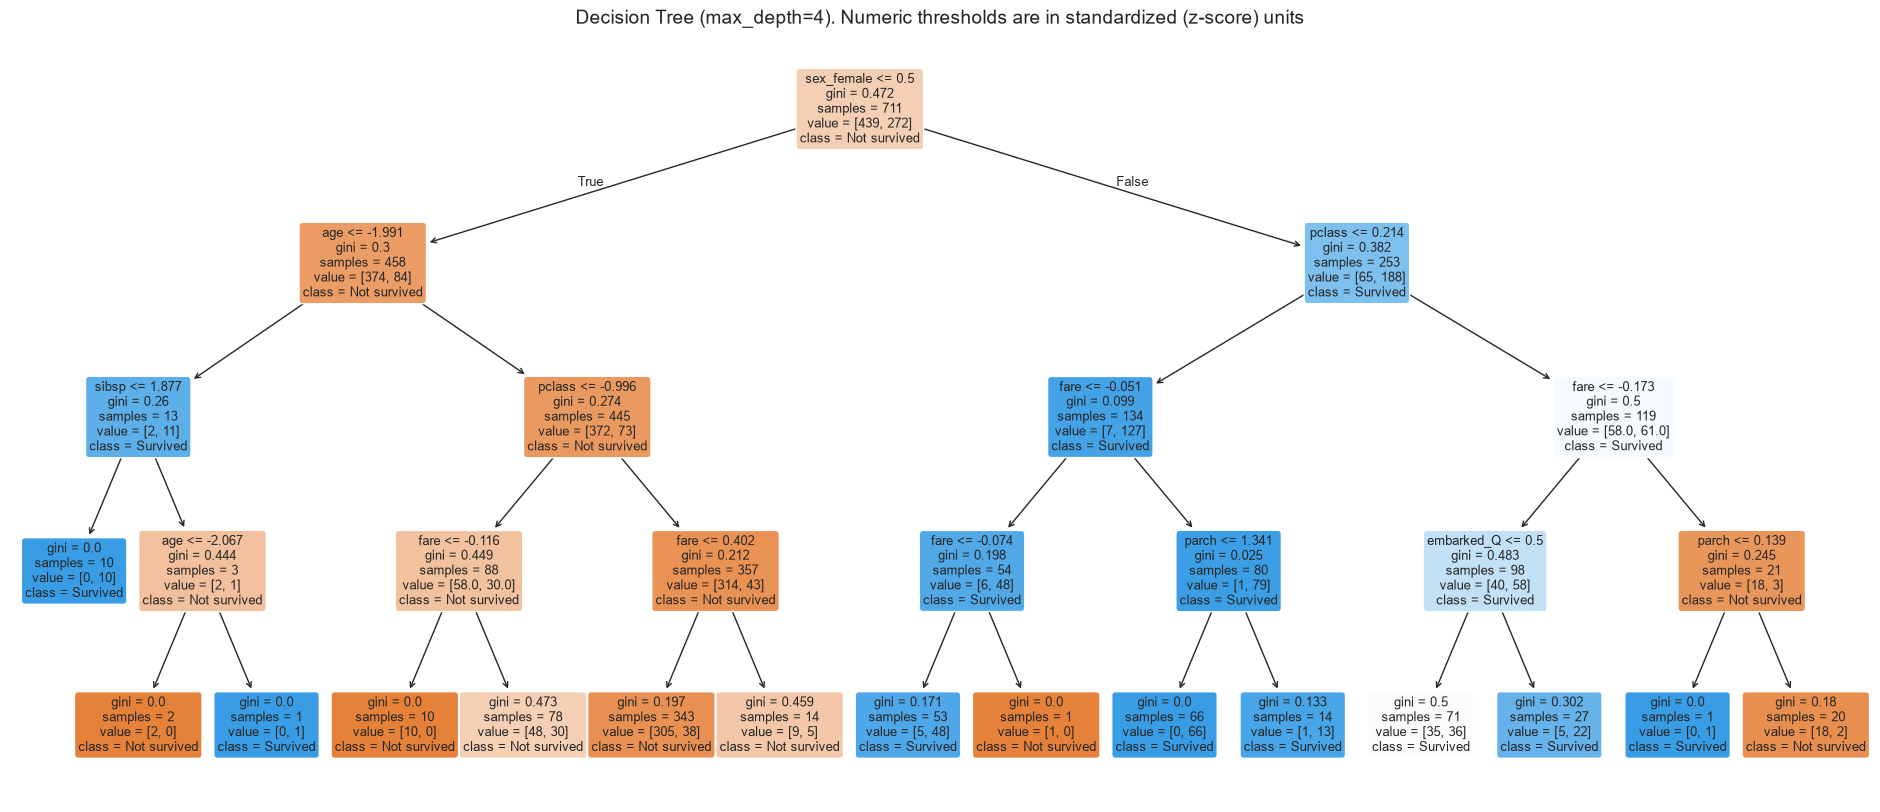

In [6]:
tree_pipe = fitted["Decision Tree"]
feature_names = [n.split("__", 1)[1] for n in tree_pipe.named_steps["prep"].get_feature_names_out()]
print("Encoded feature names:", feature_names)

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(tree_pipe.named_steps["model"], feature_names=feature_names,
          class_names=["Not survived", "Survived"], filled=True, rounded=True,
          impurity=True, proportion=False, fontsize=9, ax=ax)
ax.set_title("Decision Tree (max_depth=4). Numeric thresholds are in standardized (z-score) units", fontsize=14)
save(fig, "10_decision_tree")
plt.show()

**Reading the tree.** The first split is on `sex_female`: the left branch (`sex_female <= 0.5`) holds the men.
This matches the EDA, where sex was the strongest driver.

- **Men (left branch).** The only large group predicted to survive is very young boys (`age <= −1.99` in z-units,
  i.e. about 3.5 years old or younger) with few siblings. Almost all other men are predicted "Not survived".
- **Women (right branch).** The next split is on `pclass`. Women in 1st and 2nd class (`pclass <= 0.21`) are
  predicted "Survived" with very high purity (127 of 134 training women). For 3rd-class women the outcome is
  close to a coin flip (58 vs 61), and the tree uses fare and `parch` to separate them. Cheaper fares and small
  families survive more; large families do not.

`max_depth=4` was chosen deliberately. It keeps the tree readable and limits overfitting, because an
unrestricted tree would memorise the 711 training rows. Numeric thresholds are shown in standardized units
because the tree sees the output of the pipeline's `StandardScaler`.

## 5. Evaluation — confusion matrix, accuracy, precision, recall, F1, ROC/AUC

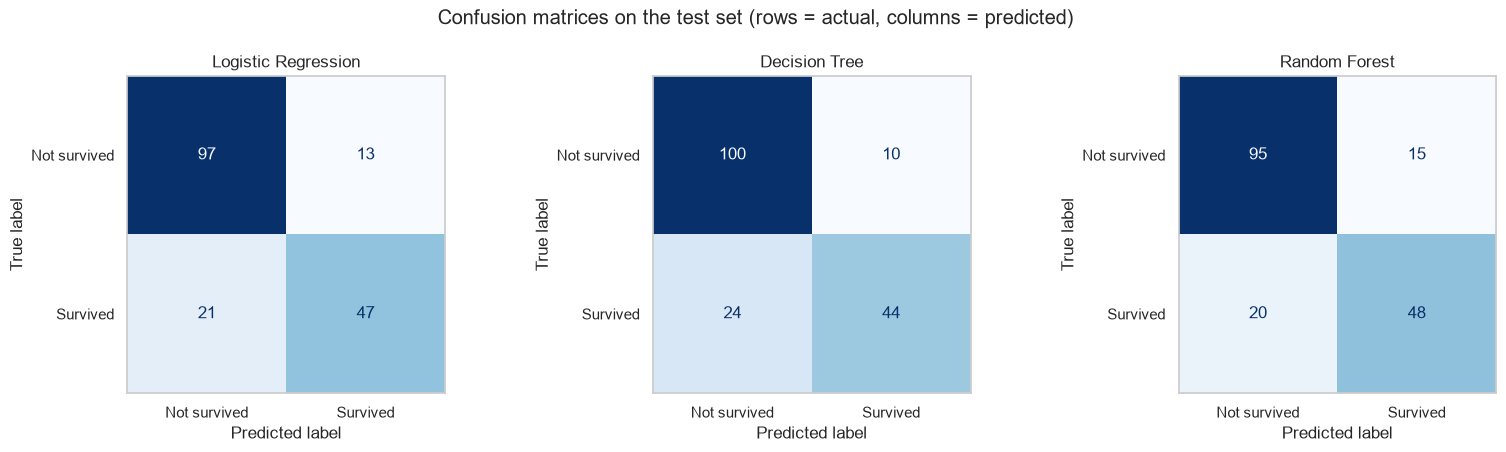

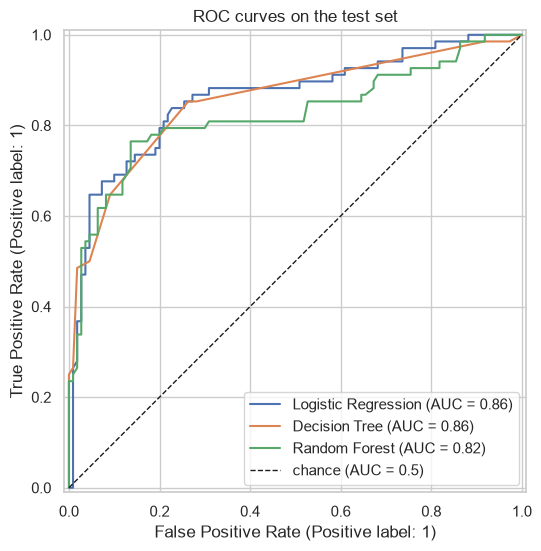

,accuracy,precision,recall,f1,auc
Logistic Regression,0.809,0.783,0.691,0.734,0.861
Decision Tree,0.809,0.815,0.647,0.721,0.856
Random Forest,0.803,0.762,0.706,0.733,0.824


In [7]:
def classification_metrics(pipe, X_eval=X_test, y_eval=y_test):
    pred = pipe.predict(X_eval)
    proba = pipe.predict_proba(X_eval)[:, 1]
    return {"accuracy": accuracy_score(y_eval, pred),
            "precision": precision_score(y_eval, pred),
            "recall": recall_score(y_eval, pred),
            "f1": f1_score(y_eval, pred),
            "auc": roc_auc_score(y_eval, proba)}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (name, pipe) in zip(axes, fitted.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, ax=ax, colorbar=False, cmap="Blues",
                                          display_labels=["Not survived", "Survived"])
    ax.set_title(name)
    ax.grid(False)
fig.suptitle("Confusion matrices on the test set (rows = actual, columns = predicted)")
fig.tight_layout()
save(fig, "11_confusion_matrices")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance (AUC = 0.5)")
ax.set_title("ROC curves on the test set")
ax.legend(loc="lower right")
save(fig, "12_roc_curves")
plt.show()

comparison = pd.DataFrame({name: classification_metrics(pipe) for name, pipe in fitted.items()}).T
comparison.round(3)

**Evaluation on the 178-row test set.**

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.809 | 0.783 | 0.691 | 0.734 | **0.861** |
| Decision Tree (depth 4) | 0.809 | **0.815** | 0.647 | 0.721 | 0.856 |
| Random Forest (default, 300 trees) | 0.803 | 0.762 | **0.706** | 0.733 | 0.824 |

**The three untuned models are very close.**

- **Logistic Regression** ranks passengers best: it has the highest AUC, 0.861.
- **Decision Tree** is the most conservative. It has the highest precision (0.815), but it misses the most
  survivors: 24 false negatives, recall 0.647.
- **Default Random Forest** catches the most survivors (recall 0.706, 20 false negatives), but it has the most
  false alarms (15) and the lowest AUC.

The untuned forest grows its trees to full depth and overfits the small training set, which is why tuning is
worth doing (section 7).

**Every model makes more false negatives than false positives.** Survivors are the minority class, which
motivates the imbalance experiment below.

## 6. Imbalance handling — baseline vs `class_weight='balanced'` vs SMOTE

Logistic Regression is retrained three ways on the same split. SMOTE sits **inside an `imblearn` Pipeline**
after the preprocessor. `imblearn` pipelines apply samplers only during `fit`, so synthetic survivors are created
from the **training fold only**, and the test set is never resampled.

Training class counts before SMOTE: {0: 439, 1: 272}
Training class counts after SMOTE : {0: 439, 1: 439}
Test class counts (never resampled): {0: 110, 1: 68} 

                             precision  recall     f1  accuracy
(a) baseline                     0.783   0.691  0.734     0.809
(b) class_weight='balanced'      0.718   0.750  0.734     0.792
(c) SMOTE (train fold only)      0.735   0.735  0.735     0.798


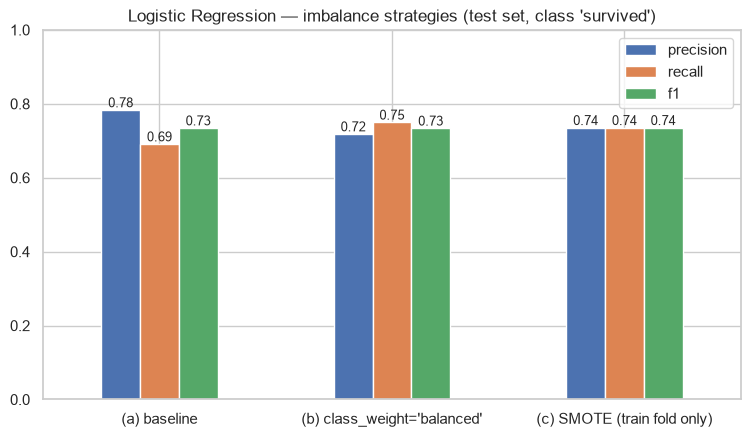

In [8]:
imbalance_variants = {
    "(a) baseline": make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "(b) class_weight='balanced'": make_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    "(c) SMOTE (train fold only)": ImbPipeline([
        ("prep", make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}
for pipe in imbalance_variants.values():
    pipe.fit(X_train, y_train)

# Show what SMOTE did to the *training* data (the test set is untouched)
Xt = imbalance_variants["(c) SMOTE (train fold only)"].named_steps["prep"].transform(X_train)
_, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(Xt, y_train)
print("Training class counts before SMOTE:", y_train.value_counts().sort_index().to_dict())
print("Training class counts after SMOTE :", pd.Series(y_res).value_counts().sort_index().to_dict())
print("Test class counts (never resampled):", y_test.value_counts().sort_index().to_dict(), "\n")

imbalance = pd.DataFrame({n: classification_metrics(p) for n, p in imbalance_variants.items()}).T
print(imbalance[["precision", "recall", "f1", "accuracy"]].round(3).to_string())

ax = imbalance[["precision", "recall", "f1"]].plot.bar(figsize=(9, 4.8), rot=0,
                                                      color=["#4C72B0", "#DD8452", "#55A868"])
ax.set(title="Logistic Regression — imbalance strategies (test set, class 'survived')", ylim=(0, 1))
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=9)
save(ax.figure, "13_imbalance_comparison")
plt.show()

**Class balance.** The training split has 439 non-survivors against 272 survivors (61.7 % / 38.3 %). SMOTE
oversampled only the training data, to 439 / 439. The test set keeps its real 110 / 68.

| Variant | Precision | Recall | F1 |
|---|---|---|---|
| (a) baseline | **0.783** | 0.691 | 0.734 |
| (b) `class_weight='balanced'` | 0.718 | **0.750** | 0.734 |
| (c) SMOTE (train only) | 0.735 | 0.735 | **0.735** |

**Conclusion.** Both balancing strategies do what they should: they shift the decision boundary towards the
minority class.

- **Recall rises**, from 0.691 to 0.750 with `class_weight` and to 0.735 with SMOTE, so 4 more survivors are
  caught with `class_weight`.
- **Precision falls** by the same amount, so **F1 stays essentially unchanged** at about 0.734. SMOTE is only
  0.001 ahead, which is noise on a 178-row test set.

The imbalance here is only moderate (38 / 62), so no strategy produces a real F1 gain: they trade precision for
recall. **The strategy that worked best is `class_weight='balanced'`.** It gives the largest recall gain
(+5.9 points) at no F1 cost, needs no synthetic data and no extra library, and cannot introduce oversampling
artefacts. If catching every possible survivor matters more than false alarms, it is the one to use. SMOTE
reaches a similar result with more machinery.

## 7. Hyperparameter tuning — `GridSearchCV` on Random Forest (with OOB score)

The estimator is constructed as `RandomForestClassifier(oob_score=True, ...)` so that `oob_score_` is populated.
The whole pipeline (preprocessor + forest) is cross-validated, so the preprocessing is re-fitted inside every
CV training fold as well.

In [9]:
rf_search_pipe = make_pipeline(
    RandomForestClassifier(oob_score=True, random_state=RANDOM_STATE)
)
param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [4, 6, 8, None],
    "model__max_features": ["sqrt", "log2", None],
}
grid = GridSearchCV(
    rf_search_pipe, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1", n_jobs=-1,
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print(f"Combinations tried : {len(grid.cv_results_['params'])} x 5 folds")
print("Best parameters    :", {k.replace('model__', ''): v for k, v in grid.best_params_.items()})
print(f"Best mean CV F1    : {grid.best_score_:.4f}")
print(f"OOB score (accuracy on out-of-bag samples of the refitted best forest): "
      f"{best_rf.named_steps['model'].oob_score_:.4f}")

top = (pd.DataFrame(grid.cv_results_)
       .sort_values("rank_test_score")
       .loc[:, ["param_model__n_estimators", "param_model__max_depth", "param_model__max_features",
                "mean_test_score", "std_test_score"]]
       .head(8))
top.columns = ["n_estimators", "max_depth", "max_features", "mean_cv_f1", "std_cv_f1"]
top.round(4)

Combinations tried : 36 x 5 folds
Best parameters    : {'max_depth': 8, 'max_features': None, 'n_estimators': 400}
Best mean CV F1    : 0.7722
OOB score (accuracy on out-of-bag samples of the refitted best forest): 0.8326


,n_estimators,max_depth,max_features,mean_cv_f1,std_cv_f1
26,400,8,None,0.7722,0.0035
24,100,8,None,0.7685,0.0099
21,100,8,log2,0.7628,0.0366
18,100,8,sqrt,0.7628,0.0366
35,400,None,None,0.7627,0.0097
23,400,8,log2,0.7621,0.0277
20,400,8,sqrt,0.7621,0.0277
33,100,None,None,0.7604,0.0192


In [10]:
comparison.loc["Random Forest (tuned)"] = classification_metrics(best_rf)
comparison.round(3)

,accuracy,precision,recall,f1,auc
Logistic Regression,0.809,0.783,0.691,0.734,0.861
Decision Tree,0.809,0.815,0.647,0.721,0.856
Random Forest,0.803,0.762,0.706,0.733,0.824
Random Forest (tuned),0.831,0.828,0.706,0.762,0.841


**Tuning result.**

- **Search space.** 36 combinations × 5 stratified folds, scored by **F1**. F1 balances precision and recall on
  the minority class, which accuracy alone would not.
- **Best parameters:** `n_estimators=400`, `max_depth=8`, `max_features=None`, with a mean CV F1 of **0.772**
  (std 0.004).
- **OOB score:** **0.833**. That is the accuracy of the refitted best forest on the training rows each tree did
  *not* see in its bootstrap sample, a built-in validation estimate that needs no extra data.

**Capping `max_depth` at 8 is what helped.** It stops the trees from memorising the training set. All of the
top 8 combinations use depth 8 or unlimited, and depth 8 wins.

**On the test set** the tuned forest improves on the default forest in every metric except recall (which is
unchanged):

- accuracy 0.803 → **0.831**
- precision 0.762 → **0.828**
- F1 0.733 → **0.762**
- AUC 0.824 → 0.841

Its test accuracy (0.831) agrees closely with the OOB estimate (0.833), which suggests the model generalises as
expected rather than having been lucky on this split.

## 8. Regression side-task — predict `fare`

Multivariate linear regression, predicting `fare` from `pclass, sex, age, sibsp, parch, embarked`, using the
same preprocessing design, fitted on a training split only.

In [11]:
REG_NUM = ["pclass", "age", "sibsp", "parch"]
REG_CAT = ["sex", "embarked"]
Xr, yr = df[REG_NUM + REG_CAT], df["fare"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

reg_pipe = Pipeline([("prep", make_preprocessor(REG_NUM, REG_CAT)), ("model", LinearRegression())])
reg_pipe.fit(Xr_train, yr_train)
yr_pred = reg_pipe.predict(Xr_test)

n = len(yr_test)
p = len(reg_pipe.named_steps["prep"].get_feature_names_out())   # predictors after one-hot encoding
r2 = r2_score(yr_test, yr_pred)
regression_metrics = {
    "MAE": mean_absolute_error(yr_test, yr_pred),
    "RMSE": np.sqrt(mean_squared_error(yr_test, yr_pred)),
    "R2": r2,
    "Adjusted R2": 1 - (1 - r2) * (n - 1) / (n - p - 1),
}
print(f"test rows n = {n}, predictors p = {p}")
for k, v in regression_metrics.items():
    print(f"{k:12s}: {v:.4f}")

coefs = pd.Series(reg_pipe.named_steps["model"].coef_,
                  index=[f.split("__", 1)[1] for f in reg_pipe.named_steps["prep"].get_feature_names_out()])
print("\nCoefficients (per 1 std for numeric features, per category for one-hot):")
print(coefs.round(2).sort_values().to_string())

test rows n = 178, predictors p = 9
MAE         : 21.1398
RMSE        : 41.7465
R2          : 0.3468
Adjusted R2 : 0.3118

Coefficients (per 1 std for numeric features, per category for one-hot):
pclass       -26.96
embarked_S    -8.69
sex_male      -2.23
age           -1.57
embarked_Q    -1.04
sex_female     2.23
sibsp          7.16
parch          8.85
embarked_C     9.74


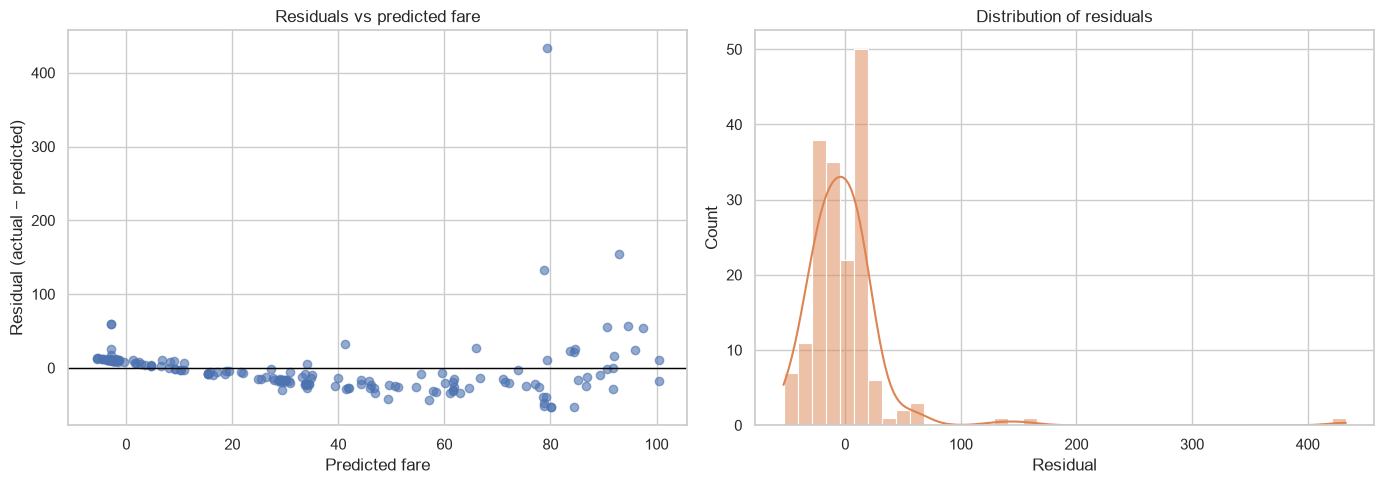

                   count  residual_std
(-5.62, 0.00371]      45         10.35
(0.00371, 29.463]     44          9.28
(29.463, 60.77]       44         12.16
(60.77, 100.445]      45         78.07


In [12]:
residuals = yr_test - yr_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(yr_pred, residuals, alpha=0.6, color="#4C72B0")
axes[0].axhline(0, color="black", lw=1)
axes[0].set(title="Residuals vs predicted fare", xlabel="Predicted fare", ylabel="Residual (actual − predicted)")
sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color="#DD8452")
axes[1].set(title="Distribution of residuals", xlabel="Residual")
fig.tight_layout()
save(fig, "14_regression_residuals")
plt.show()

# Quantify the spread of residuals across ranges of the prediction
bands = pd.qcut(pd.Series(yr_pred, index=yr_test.index), q=4)
print(residuals.groupby(bands, observed=True).agg(["count", "std"]).round(2)
      .rename(columns={"std": "residual_std"}).to_string())

**Regression results.**

| MAE | RMSE | R² | Adjusted R² |
|---|---|---|---|
| 21.14 | 41.75 | 0.347 | 0.312 |

- **Fit.** The model explains about **35 %** of the variance in fare. Adjusted R² (n = 178 test rows,
  p = 9 predictors after one-hot encoding) is slightly lower at 0.312, which penalises the extra predictors.
- **Coefficients.** `pclass` dominates: one standard deviation towards a cheaper class lowers the predicted fare
  by about 27. Larger families (`parch`, `sibsp`) and boarding at Cherbourg raise it.
- **Error measures.** RMSE is about twice the MAE, a sign that a few very large errors dominate. These are the
  extreme first-class fares, such as 512.33.

**Heteroscedasticity: yes, clearly present.** The residuals do **not** form an even band around zero; they fan
out as the prediction grows.

- **Residual spread by quartile of predicted fare:** 10.4, 9.3 and 12.2 for the three lower quartiles, then
  **78.1** for the top quartile.
- **Why.** Cheap third-class fares are all similar, while first-class fares range from about 25 to 512, and a
  linear model cannot capture that growing spread.
- **Other warning signs.** The residuals also show a curved pattern: positive at low predictions, negative in
  the middle. The model even predicts slightly *negative* fares for some third-class passengers. Both show that
  a straight-line model is a poor fit for this skewed target.

Modelling `log(fare)`, or using a tree-based regressor, would be the natural next step. It was not required
here, so the plain multivariate linear regression is reported as asked.

## 9. Final model comparison table

In [13]:
reg_row = pd.Series(regression_metrics, name="Linear Regression (fare)")
final_table = pd.concat(
    {"Classification metrics (target: survived)": comparison,
     "Regression metrics (target: fare)": pd.DataFrame([reg_row])},
    axis=1,
)
final_table.round(3).astype(object).where(final_table.notna(), "—")

Classification metrics (target: survived)                                Regression metrics (target: fare)                           
                                                          accuracy precision recall     f1    auc                               MAE    RMSE     R2 Adjusted R2
Logistic Regression                                          0.809     0.783  0.691  0.734  0.861                                 —       —      —           —
Decision Tree                                                0.809     0.815  0.647  0.721  0.856                                 —       —      —           —
Random Forest                                                0.803     0.762  0.706  0.733  0.824                                 —       —      —           —
Random Forest (tuned)                                        0.831     0.828  0.706  0.762  0.841                                 —       —      —           —
Linear Regression (fare)                                         —         —      —      —      —                             21.14  41.747  0.347       0.312

**How to read this table.** It has two separate metric groups. The **classification** columns (accuracy,
precision, recall, F1 and AUC, all between 0 and 1, higher is better) apply to the four `survived` classifiers.
The **regression** columns (MAE and RMSE in fare units where lower is better, and R² / adjusted R² where higher
is better) apply only to the `fare` model. The two groups measure different things on different scales and are
not comparable with each other; "—" marks metrics that do not apply to a model.

### Recommendation — which classifier to deploy

**Deploy the tuned Random Forest.**

- **Best on the core metrics.** It has the best test accuracy (**0.831**), precision (**0.828**) and F1
  (**0.762**) of all the classifiers. It beats the next-best F1 (Logistic Regression, 0.734) by almost 3 points
  while producing the fewest false alarms (10, tied with the Decision Tree).
- **Trustworthy generalisation.** Its OOB estimate (0.833) and cross-validated F1 (0.772, std 0.004) agree with
  the test result, so the performance is stable rather than a lucky split.
- **Where Logistic Regression still wins.** It keeps a slightly higher AUC (0.861 against 0.841), so it ranks
  passengers by probability a little better. It is also more interpretable, and would be the better choice if
  calibrated probabilities or explainability mattered more than the final yes/no decision.
- **If recall is the priority.** The forest could additionally be trained with `class_weight='balanced'`, as
  section 6 showed.

## 10. Save the complete best pipeline and reload it on raw data

In [14]:
BEST_NAME = "Random Forest (tuned)"
candidates = {**fitted, "Random Forest (tuned)": best_rf}
full_pipeline = candidates[BEST_NAME]
print("Saving:", BEST_NAME)
print(full_pipeline)

MODEL_PATH = MODEL_DIR / "titanic_survival_pipeline.joblib"
joblib.dump(full_pipeline, MODEL_PATH)
print(f"\nSaved -> {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024:.0f} KB)")

Saving: Random Forest (tuned)
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncod


Saved -> models\titanic_survival_pipeline.joblib  (3827 KB)


In [15]:
# --- Reload in a "fresh" way and use it on RAW, unpreprocessed input ---
loaded = joblib.load(MODEL_PATH)

# 1) Identical behaviour to the in-memory pipeline on the untouched raw test rows
assert (loaded.predict(X_test) == full_pipeline.predict(X_test)).all()
print(f"Reloaded pipeline reproduces the in-memory predictions on all {len(X_test)} test rows.")
print("Reloaded test accuracy:", round(accuracy_score(y_test, loaded.predict(X_test)), 3))

# 2) Brand-new raw passengers: plain strings, original units, even a missing age
new_passengers = pd.DataFrame([
    {"pclass": 1, "age": 29,     "sibsp": 0, "parch": 0, "fare": 211.34, "sex": "female", "embarked": "S"},
    {"pclass": 3, "age": 24,     "sibsp": 0, "parch": 0, "fare": 7.90,   "sex": "male",   "embarked": "S"},
    {"pclass": 2, "age": np.nan, "sibsp": 1, "parch": 2, "fare": 26.00,  "sex": "female", "embarked": "C"},
    {"pclass": 3, "age": 4,      "sibsp": 1, "parch": 1, "fare": 16.70,  "sex": "male",   "embarked": "Q"},
])
new_passengers["predicted_survived"] = loaded.predict(new_passengers[FEATURES])
new_passengers["p_survive"] = loaded.predict_proba(new_passengers[FEATURES])[:, 1].round(3)
new_passengers

Reloaded pipeline reproduces the in-memory predictions on all 178 test rows.
Reloaded test accuracy: 0.831


,pclass,age,sibsp,parch,fare,sex,embarked,predicted_survived,p_survive
0,1,29.0,0,0,211.34,female,S,1,0.998
1,3,24.0,0,0,7.90,male,S,0,0.050
2,2,NaN,1,2,26.00,female,C,1,0.768
3,3,4.0,1,1,16.70,male,Q,1,0.821


**Saved artifact.** `models/titanic_survival_pipeline.joblib` holds the **complete fitted pipeline**:
`ColumnTransformer` (median imputer + scaler, most-frequent imputer + one-hot encoder) → tuned
`RandomForestClassifier`. It is not the bare estimator. After `joblib.load`:

1. It reproduces the in-memory predictions exactly on all 178 raw test rows (checked with `assert`), with the
   same accuracy of 0.831.
2. It scores brand-new passengers given as **raw values**: plain `"female"`/`"male"` strings, fares in original
   units, and even a missing `age` (`NaN`), which the saved imputer fills with the training median. No manual
   preprocessing is needed.

The predictions also make sense:

- A 1st-class woman: **p = 0.998**.
- A 24-year-old 3rd-class man travelling alone: **p = 0.05**.
- A 4-year-old boy travelling with family: **p = 0.82**. This is the "children first" pattern from the EDA.